In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_data.csv")
print(df)

        InvoiceNo StockCode                          Description  Quantity  \
0          536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1          536365     71053                  WHITE METAL LANTERN         6   
2          536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3          536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4          536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...           ...       ...                                  ...       ...   
397919     581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
397920     581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
397921     581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
397922     581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
397923     581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

                InvoiceDate  UnitPrice  CustomerID         Coun

> Sales Distribution

In [3]:
df["Revenue"].describe()

count    397924.000000
mean         22.394749
std         309.055588
min           0.000000
25%           4.680000
50%          11.800000
75%          19.800000
max      168469.600000
Name: Revenue, dtype: float64

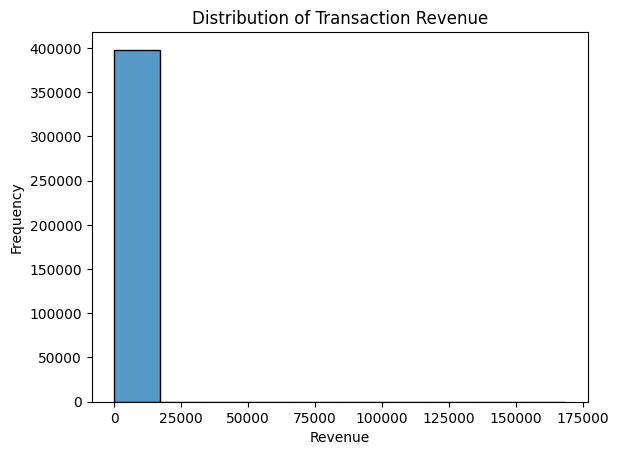

In [10]:
sns.histplot(data = df , x = "Revenue",bins=10)
plt.title("Distribution of Transaction Revenue")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

- Few transactions contribute very high revenue, showing right-skewed distribution.

> Purchase Quantity Distribution

In [8]:
df["Quantity"].describe()

count    397924.000000
mean         13.021823
std         180.420210
min           1.000000
25%           2.000000
50%           6.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64

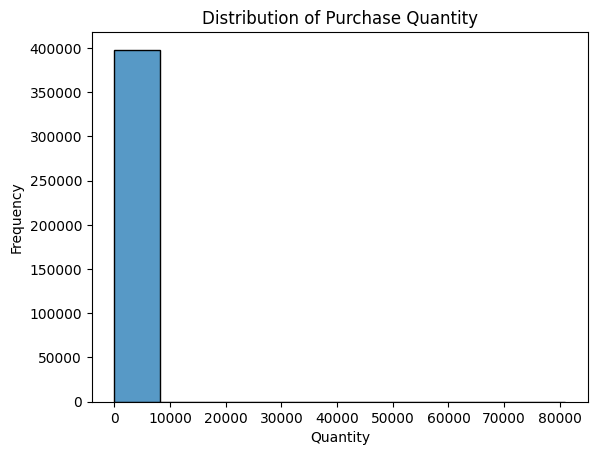

In [11]:
sns.histplot(df['Quantity'], bins=10)
plt.title("Distribution of Purchase Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

> Customer Purchase Frequecy

In [13]:
customer_order = df.groupby("CustomerID")["InvoiceNo"].nunique()
print(customer_order)

CustomerID
12346.0     1
12347.0     7
12348.0     4
12349.0     1
12350.0     1
           ..
18280.0     1
18281.0     1
18282.0     2
18283.0    16
18287.0     3
Name: InvoiceNo, Length: 4339, dtype: int64


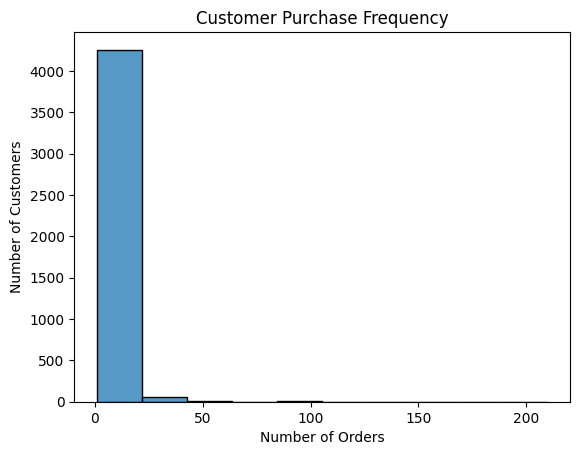

In [15]:
sns.histplot(customer_order, bins=10)
plt.title("Customer Purchase Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.show()

> Average Order Value

In [4]:
order_value = df.groupby("InvoiceNo")["Revenue"].sum()
print(order_value)

InvoiceNo
536365    139.12
536366     22.20
536367    278.73
536368     70.05
536369     17.85
           ...  
581583    124.60
581584    140.64
581585    329.05
581586    339.20
581587    249.45
Name: Revenue, Length: 18536, dtype: float64


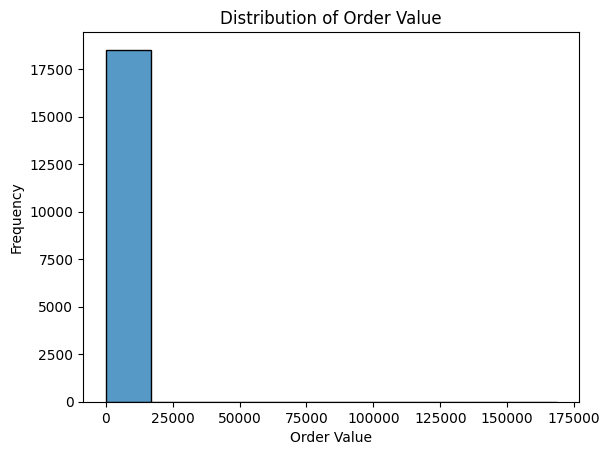

In [17]:
sns.histplot(order_value, bins=10)
plt.title("Distribution of Order Value")
plt.xlabel("Order Value")
plt.ylabel("Frequency")
plt.show()

> Number of Products Order

In [24]:
basket_size = df.groupby('InvoiceNo')['Quantity'].sum()
print(basket_size)

InvoiceNo
536365     40
536366     12
536367     83
536368     15
536369      3
         ... 
581583     76
581584    120
581585    278
581586     66
581587    105
Name: Quantity, Length: 18536, dtype: int64


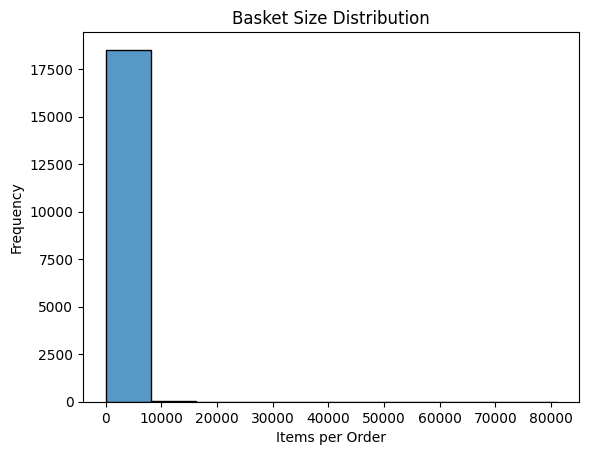

In [28]:
sns.histplot(basket_size, bins=10)
plt.title("Basket Size Distribution")
plt.xlabel("Items per Order")
plt.ylabel("Frequency")
plt.show()

> Country Purchasing Behaviour

In [25]:
country_behaviour = df.groupby('Country')['Quantity'].mean()
print(country_behaviour)

Country
Australia               71.062447
Austria                 12.263819
Bahrain                 15.294118
Belgium                 11.441162
Brazil                  11.125000
Canada                  18.298013
Channel Islands         12.688503
Cyprus                  10.359935
Czech Republic          26.840000
Denmark                 21.671053
EIRE                    19.414894
European Community       8.316667
Finland                 15.626277
France                  13.362743
Germany                 13.189892
Greece                  10.737931
Iceland                 13.505495
Israel                  16.314516
Italy                   10.701847
Japan                   81.046729
Lebanon                  8.577778
Lithuania               18.628571
Malta                    8.660714
Netherlands             85.034702
Norway                  18.039179
Poland                  11.163636
Portugal                11.027360
RSA                      6.068966
Saudi Arabia             8.888889
Singap

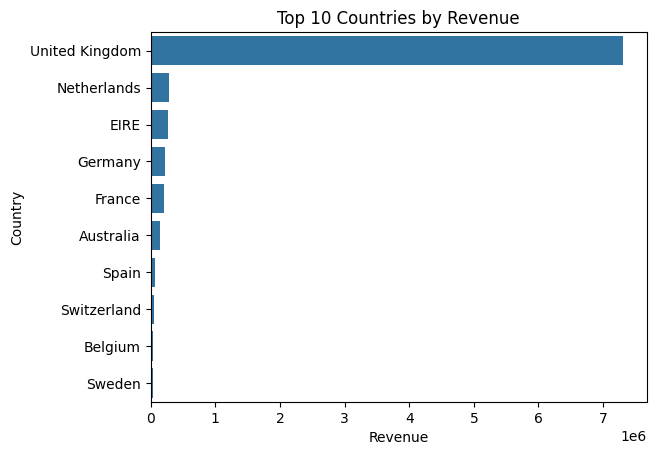

In [29]:
country_sales = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

sns.barplot(x=country_sales.values, y=country_sales.index)
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.show()

> Product Demand Variability

In [26]:
product_variability = df.groupby('Description')['Quantity'].std()
print(product_variability)

Description
 4 PURPLE FLOCK DINNER CANDLES       3.918364
 50'S CHRISTMAS GIFT BAG LARGE      37.765677
 DOLLY GIRL BEAKER                  54.793068
 I LOVE LONDON MINI BACKPACK         9.137097
 I LOVE LONDON MINI RUCKSACK              NaN
                                      ...    
ZINC T-LIGHT HOLDER STARS SMALL     30.467286
ZINC TOP  2 DOOR WOODEN SHELF        0.333333
ZINC WILLIE WINKIE  CANDLE STICK    17.377067
ZINC WIRE KITCHEN ORGANISER          1.311372
ZINC WIRE SWEETHEART LETTER TRAY     5.201214
Name: Quantity, Length: 3877, dtype: float64


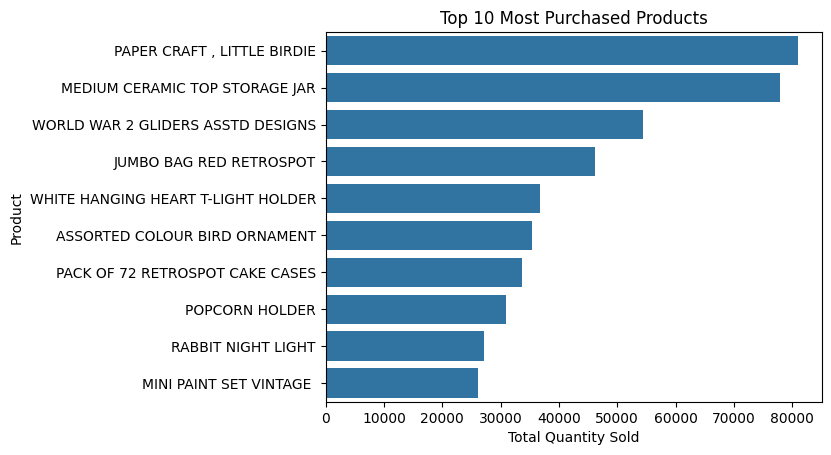

In [30]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10) 
sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Top 10 Most Purchased Products")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")
plt.show()